### Shapes, Batches & What Actually Flows Through the Model

This module is just to understand in depth of what goes in, how it works and what comes out when training a model.

### Step 0: Same as before (skip/collapse)

In [1]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

X = data.data
y = data.target

In [2]:
import torch

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [ ]:
from torch.utils.data import Dataset, DataLoader

class HousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [7]:
train_ds = HousingDataset(X_train, y_train)
test_ds = HousingDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

In [8]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(X.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

In [10]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []

for epoch in range(5):
    for xb, yb in train_loader:
        preds = model(xb)
        loss = loss_fn(preds, yb)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        train_losses.append(loss.item())
        print(f"Epoch: {epoch} | Loss: {loss.item():.4f}")

Epoch: 0 | Loss: 4779.9922
Epoch: 0 | Loss: 2298.7327
Epoch: 0 | Loss: 1045.8226
Epoch: 0 | Loss: 196.2404
Epoch: 0 | Loss: 4.0284
Epoch: 0 | Loss: 189.9469
Epoch: 0 | Loss: 388.3676
Epoch: 0 | Loss: 1092.6907
Epoch: 0 | Loss: 1076.6190
Epoch: 0 | Loss: 647.0809
Epoch: 0 | Loss: 643.2649
Epoch: 0 | Loss: 821.6777
Epoch: 0 | Loss: 336.4370
Epoch: 0 | Loss: 186.8376
Epoch: 0 | Loss: 67.5637
Epoch: 0 | Loss: 12.7826
Epoch: 0 | Loss: 8.0335
Epoch: 0 | Loss: 43.3552
Epoch: 0 | Loss: 117.6240
Epoch: 0 | Loss: 199.0477
Epoch: 0 | Loss: 248.1867
Epoch: 0 | Loss: 258.5374
Epoch: 0 | Loss: 278.3623
Epoch: 0 | Loss: 450.1822
Epoch: 0 | Loss: 126.0548
Epoch: 0 | Loss: 40.2761
Epoch: 0 | Loss: 5.6303
Epoch: 0 | Loss: 8.7798
Epoch: 0 | Loss: 30.5574
Epoch: 0 | Loss: 70.1964
Epoch: 0 | Loss: 294.3391
Epoch: 0 | Loss: 186.3950
Epoch: 0 | Loss: 63.0833
Epoch: 0 | Loss: 73.0590
Epoch: 0 | Loss: 51.5778
Epoch: 0 | Loss: 27.3362
Epoch: 0 | Loss: 5.8138
Epoch: 0 | Loss: 2.4636
Epoch: 0 | Loss: 14.6542
Epoc

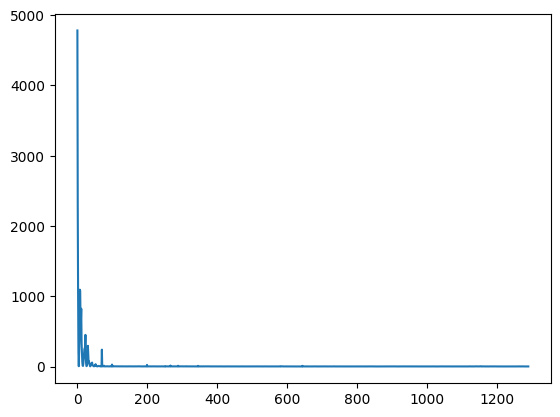

In [11]:
import matplotlib.pyplot as plt

plt.plot(train_losses)

### Step 1: One real batch from DataLoader

In [ ]:
xb, yb = next(iter(train_loader))

print("xb shape:", xb.shape)
print("yb shape:", yb.shape)

xb shape: torch.Size([64, 8])
yb shape: torch.Size([64, 1])


Meaning:
- 64 samples in this batch
- each sample has 8 features
- each output is one value

### Step 2: Pass batch through the model

In [15]:
preds = model(xb)
print("preds shape: ", preds.shape)

preds shape:  torch.Size([64, 1])


Important:
- input batch → output batch
- model never sees “one row” during training
- it always sees batches

### Step 3: What happens inside the model (layer by layer)

##### 1:

In [ ]:
nn.Linear(8, 64)

Linear(in_features=8, out_features=64, bias=True)

Takes:

`[64, 8]`


Produces:

`[64, 64]`

##### 2:

In [18]:
nn.ReLU()

ReLU()

Shape stays:

`[64, 64]`

##### 3:

In [19]:
nn.Linear(64, 1)

Linear(in_features=64, out_features=1, bias=True)

Produces:

`[64, 1]`

### Step 4: Why shapes matter more than values

At this stage:
- values are random
- shapes must be correct

If shapes mismatch:
- PyTorch throws an error
- training stops

This is why:
- most bugs are shape bugs
- professionals print shapes constantly

### Step 5: Loss also works on batches

In [20]:
loss = loss_fn(preds, yb)
print(loss)

tensor(1.1386, grad_fn=<MseLossBackward0>)


Loss:
- compares 64 predictions
- with 64 true values
- returns one number

That number = “how wrong this batch is”.